In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("../DATA/cleaned_loan_data.csv")

In [13]:
df.head()

,loan_id,applicant_id,customer_name,gender,date_of_birth,age,marital_status,education,occupation,employment_type,...,recovery_amount,loan_officer_id,loan_officer_name,payment_history_score,bounce_count,risk_category,customer_segment,is_fraud_suspected,kyc_verified,channel
0,LN157322,AP257322,Sunil Mukherjee,Male,1998-10-02,28,Married,Post Graduate,Retail Business Owner,Business Owner,...,95223.0,OFF0073,Vivaan Kulkarni,446.0,5,Low,Mass Market,No,Yes,Digital App
1,LN200595,AP300595,Dinesh Naidu,Male,2003-04-13,23,Married,Post Graduate,Trading Company Owner,Business Owner,...,0.0,OFF0080,Aarav Patil,900.0,1,Low,Mass Market,No,Yes,Digital App
2,LN152399,AP252399,Karan Naidu,Male,1990-02-11,36,Divorced,Professional Degree,Manager,Salaried,...,0.0,OFF0112,Usha Sinha,836.0,1,Low,Mass Affluent,No,Yes,Branch Walk-in
3,LN192773,AP292773,Vihaan Rathore,Male,1979-11-04,47,Married,Professional Degree,Bank Employee,Salaried,...,0.0,OFF0015,Aarav More,868.0,0,Low,Premium,No,Yes,Corporate Tie-up
4,LN133442,AP233442,Komal Pillai,Female,1974-11-06,52,Married,Post Graduate,Freelancer,Self-Employed Business,...,0.0,OFF0146,Sneha Bhatt,882.0,0,Low,Mass Market,No,Yes,Tele-calling


In [14]:
df.shape()


TypeError: 'tuple' object is not callable

In [15]:
df.shape

(120720, 53)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120720 entries, 0 to 120719
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   loan_id                   120720 non-null  str    
 1   applicant_id              120720 non-null  str    
 2   customer_name             120720 non-null  str    
 3   gender                    120720 non-null  str    
 4   date_of_birth             120720 non-null  str    
 5   age                       120720 non-null  int64  
 6   marital_status            120720 non-null  str    
 7   education                 120720 non-null  str    
 8   occupation                120720 non-null  str    
 9   employment_type           120720 non-null  str    
 10  employer_name             120720 non-null  str    
 11  years_with_employer       120720 non-null  float64
 12  annual_income             120720 non-null  float64
 13  monthly_income            120720 non-null  float64
 14 

In [17]:
date_cols = [
    "date_of_birth",
    "application_date",
    "approval_date",
    "disbursal_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

ValueError: time data "26/01/2023" doesn't match format "%d %b %Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [18]:
date_cols = [
    "date_of_birth",
    "application_date",
    "approval_date",
    "disbursal_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        format="mixed",
        dayfirst=True
    )

In [19]:
df[date_cols].isnull().sum()

date_of_birth       0
application_date    0
approval_date       0
disbursal_date      0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120720 entries, 0 to 120719
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   loan_id                   120720 non-null  str           
 1   applicant_id              120720 non-null  str           
 2   customer_name             120720 non-null  str           
 3   gender                    120720 non-null  str           
 4   date_of_birth             120720 non-null  datetime64[us]
 5   age                       120720 non-null  int64         
 6   marital_status            120720 non-null  str           
 7   education                 120720 non-null  str           
 8   occupation                120720 non-null  str           
 9   employment_type           120720 non-null  str           
 10  employer_name             120720 non-null  str           
 11  years_with_employer       120720 non-null  float64       
 12  annual_income

In [21]:
df.to_csv("../DATA/cleaned_loan_data.csv", index=False)
print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [22]:
df.shape

(120720, 53)

In [23]:
df.describe()

,date_of_birth,age,years_with_employer,annual_income,monthly_income,pincode,loan_amount,sanctioned_amount,disbursed_amount,interest_rate,...,existing_emi_obligations,collateral_value,application_date,approval_date,disbursal_date,default_flag,days_past_due,recovery_amount,payment_history_score,bounce_count
count,120720,120720.000000,120720.000000,1.207200e+05,1.207200e+05,120720.000000,1.207200e+05,1.207200e+05,1.207200e+05,120720.000000,...,120720.000000,1.207200e+05,120720,120720,120720,120720.000000,120720.000000,1.207200e+05,120720.000000,120720.000000
mean,1983-12-29 04:26:41.033797,42.502626,5.169151,8.397770e+05,7.505514e+04,404855.960189,6.081514e+05,5.683086e+05,5.597850e+05,14.393657,...,9352.650986,2.590332e+05,2024-07-21 15:08:18.131212,2024-07-28 23:36:17.176938,2024-07-30 08:43:10.854870,0.053189,10.727278,7.617816e+03,851.525737,0.722565
min,1962-01-01 00:00:00,21.000000,0.500000,1.800000e+05,1.500000e+04,110001.000000,5.000000e+04,4.500000e+04,4.500000e+04,7.000000,...,0.000000,0.000000e+00,2023-01-01 00:00:00,2023-01-02 00:00:00,2023-01-02 00:00:00,0.000000,0.000000,0.000000e+00,100.000000,0.000000
25%,1972-12-22 18:00:00,31.000000,2.800000,5.088000e+05,4.150000e+04,257489.750000,2.960000e+05,2.800000e+05,2.760000e+05,11.370000,...,0.000000,0.000000e+00,2023-10-24 00:00:00,2023-10-30 00:00:00,2023-11-01 00:00:00,0.000000,0.000000,0.000000e+00,845.000000,0.000000
50%,1983-12-21 00:00:00,43.000000,5.000000,7.236000e+05,6.030000e+04,404930.000000,4.830000e+05,4.580000e+05,4.510000e+05,13.980000,...,7099.000000,0.000000e+00,2024-08-03 00:00:00,2024-08-12 00:00:00,2024-08-13 00:00:00,0.000000,0.000000,0.000000e+00,882.000000,0.000000
75%,1995-01-19 00:00:00,54.000000,7.300000,1.029600e+06,8.790000e+04,551800.000000,7.700000e+05,7.300000e+05,7.200000e+05,17.402500,...,13543.000000,4.097722e+05,2025-04-23 00:00:00,2025-05-04 00:00:00,2025-05-06 00:00:00,0.000000,0.000000,0.000000e+00,900.000000,1.000000
max,2005-12-28 00:00:00,64.000000,19.700000,6.908400e+06,1.084120e+07,700092.000000,4.539589e+07,7.201000e+06,7.022000e+06,22.000000,...,88897.000000,8.016415e+06,2025-12-27 00:00:00,2026-05-01 00:00:00,2026-09-01 00:00:00,1.000000,360.000000,1.688535e+06,900.000000,11.000000
std,NaN,12.717552,3.145411,4.974011e+05,1.327775e+05,170002.618632,5.628461e+05,4.211705e+05,4.148593e+05,3.760014,...,10564.653000,4.499814e+05,NaN,NaN,NaN,0.224412,47.896729,4.572864e+04,97.641095,1.643593


In [ ]:
#loan_status_analysis

In [24]:
df["loan_status"].value_counts()

loan_status
Active         84264
Closed         30035
Default         5941
Written-Off      480
Name: count, dtype: int64

In [25]:
(df["loan_status"].value_counts(normalize=True) * 100).round(2)

loan_status
Active         69.80
Closed         24.88
Default         4.92
Written-Off     0.40
Name: proportion, dtype: float64

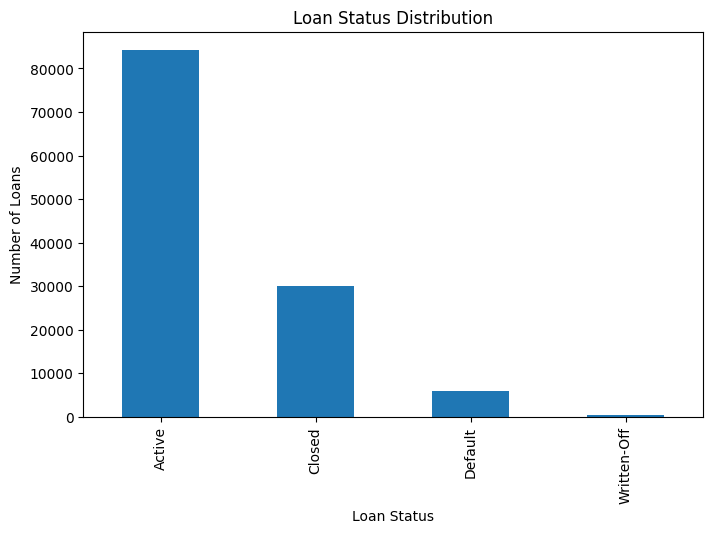

In [26]:
import matplotlib.pyplot as plt
loan_status = df["loan_status"].value_counts()
plt.figure(figsize=(8,5))
loan_status.plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.show()

In [27]:
#Customer Demographics

In [28]:
df["gender"].value_counts()

gender
Male      76026
Female    44694
Name: count, dtype: int64

In [29]:
(df["gender"].value_counts(normalize=True)*100).round(2)

gender
Male      62.98
Female    37.02
Name: proportion, dtype: float64

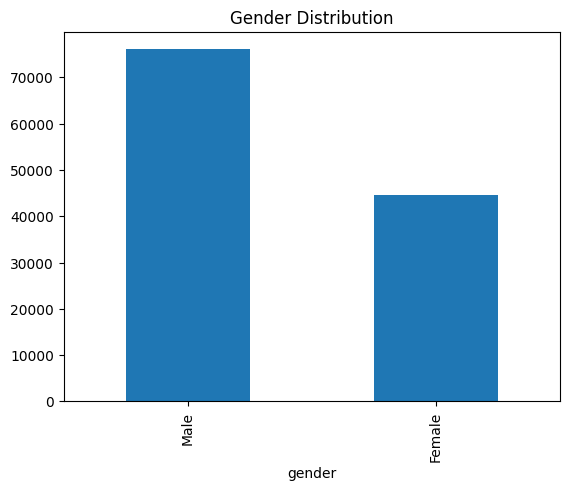

In [30]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

In [31]:
#age


In [32]:
df["age"].describe()

count    120720.000000
mean         42.502626
std          12.717552
min          21.000000
25%          31.000000
50%          43.000000
75%          54.000000
max          64.000000
Name: age, dtype: float64

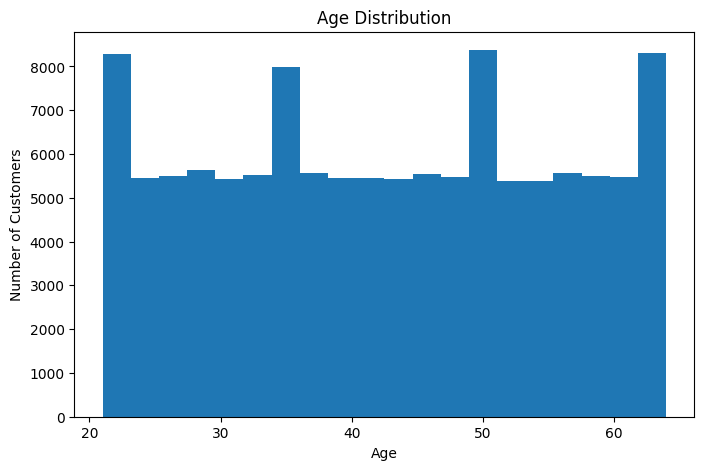

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,55,65],
    labels=["18-25","26-35","36-45","46-55","56-64"]
)

df["age_group"].value_counts().sort_index()

age_group
18-25    13744
26-35    27480
36-45    27252
46-55    27394
56-64    24850
Name: count, dtype: int64

In [35]:
# marital status analysis


In [36]:
df["marital_status"].value_counts()

marital_status
Married     70507
Single      38240
Divorced     8378
Widowed      3595
Name: count, dtype: int64

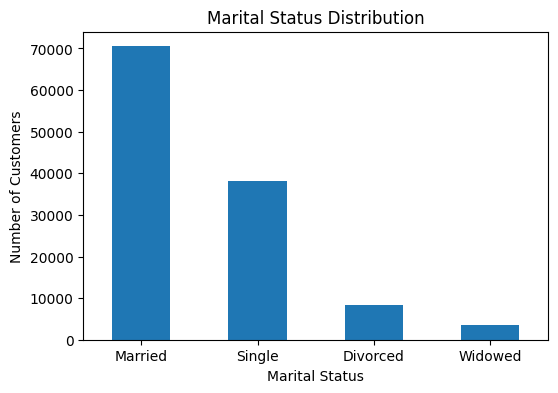

In [37]:
marital = df["marital_status"].value_counts()

plt.figure(figsize=(6,4))
marital.plot(kind="bar")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [38]:
#education analysis

In [39]:
(df["education"].value_counts(normalize=True) * 100).round(2)

education
Graduate               42.03
Post Graduate          28.05
Professional Degree    12.98
High School            11.94
Diploma                 5.00
Name: proportion, dtype: float64

In [40]:
(df["education"].value_counts(normalize=True) * 100).round(2)

education
Graduate               42.03
Post Graduate          28.05
Professional Degree    12.98
High School            11.94
Diploma                 5.00
Name: proportion, dtype: float64

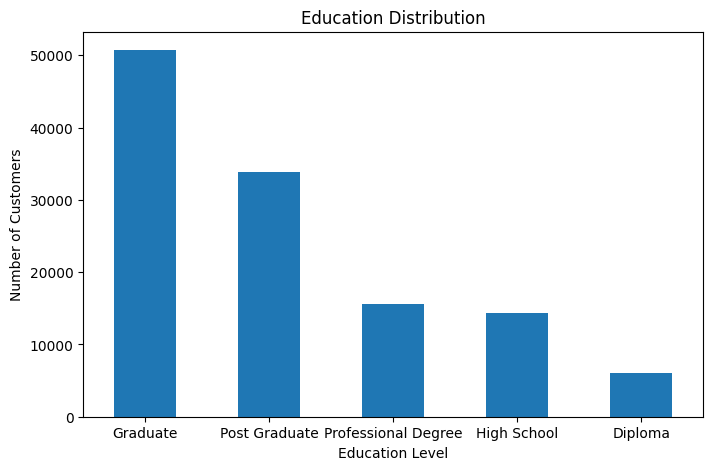

In [41]:
education = df["education"].value_counts()

plt.figure(figsize=(8,5))
education.plot(kind="bar")

plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [42]:
#occupation analysis

In [43]:
df["occupation"].value_counts()

occupation
Accountant                      7497
Manager                         7431
Software Engineer               7428
Sales Executive                 7410
Civil Engineer                  7400
Bank Employee                   7394
Government Employee             7380
Teacher                         7371
Nurse                           7194
Contractor                      6117
Shop Owner                      6056
Freelancer                      6030
Trader                          6005
Lawyer                          3663
Doctor                          3639
Consultant                      3611
Architect                       3579
Chartered Accountant            3567
Retail Business Owner           3011
Trading Company Owner           3005
Restaurant Owner                2978
Manufacturing Business Owner    2954
Name: count, dtype: int64

In [44]:
(df["occupation"].value_counts(normalize=True) * 100).round(2)

occupation
Accountant                      6.21
Manager                         6.16
Software Engineer               6.15
Sales Executive                 6.14
Civil Engineer                  6.13
Bank Employee                   6.12
Government Employee             6.11
Teacher                         6.11
Nurse                           5.96
Contractor                      5.07
Shop Owner                      5.02
Freelancer                      5.00
Trader                          4.97
Lawyer                          3.03
Doctor                          3.01
Consultant                      2.99
Architect                       2.96
Chartered Accountant            2.95
Retail Business Owner           2.49
Trading Company Owner           2.49
Restaurant Owner                2.47
Manufacturing Business Owner    2.45
Name: proportion, dtype: float64

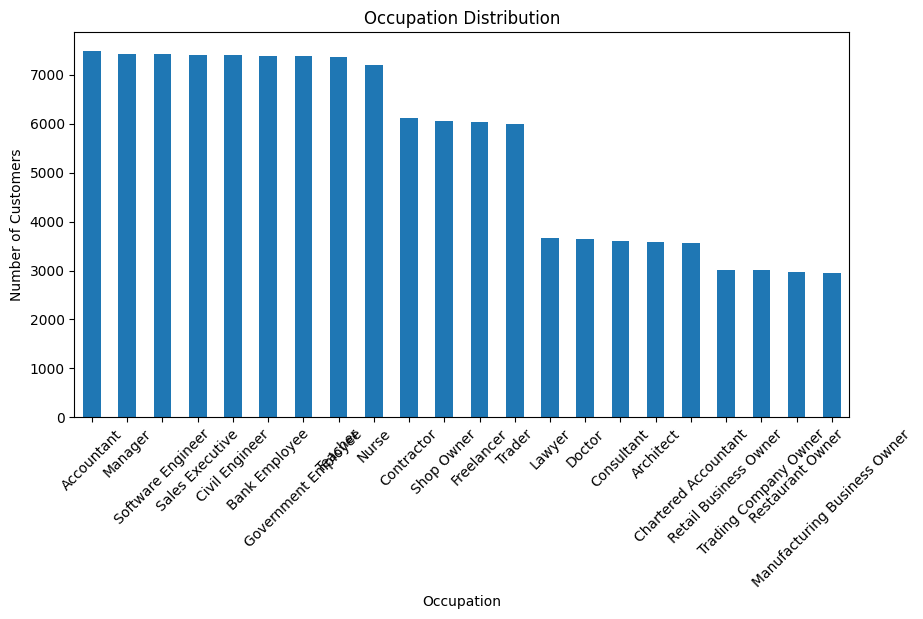

In [45]:
occupation = df["occupation"].value_counts()

plt.figure(figsize=(10,5))
occupation.plot(kind="bar")

plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

In [46]:
#Employment Type

In [47]:
df["employment_type"].value_counts()

employment_type
Salaried                      66505
Self-Employed Business        24208
Self-Employed Professional    18059
Business Owner                11948
Name: count, dtype: int64

In [48]:
(df["employment_type"].value_counts(normalize=True) * 100).round(2)

employment_type
Salaried                      55.09
Self-Employed Business        20.05
Self-Employed Professional    14.96
Business Owner                 9.90
Name: proportion, dtype: float64

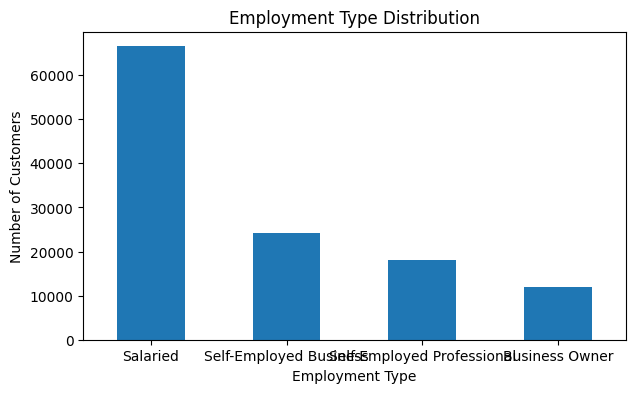

In [49]:
employment = df["employment_type"].value_counts()

plt.figure(figsize=(7,4))
employment.plot(kind="bar")

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [50]:
#Summary Statistics

In [51]:
df["annual_income"].describe()

count    1.207200e+05
mean     8.397770e+05
std      4.974011e+05
min      1.800000e+05
25%      5.088000e+05
50%      7.236000e+05
75%      1.029600e+06
max      6.908400e+06
Name: annual_income, dtype: float64

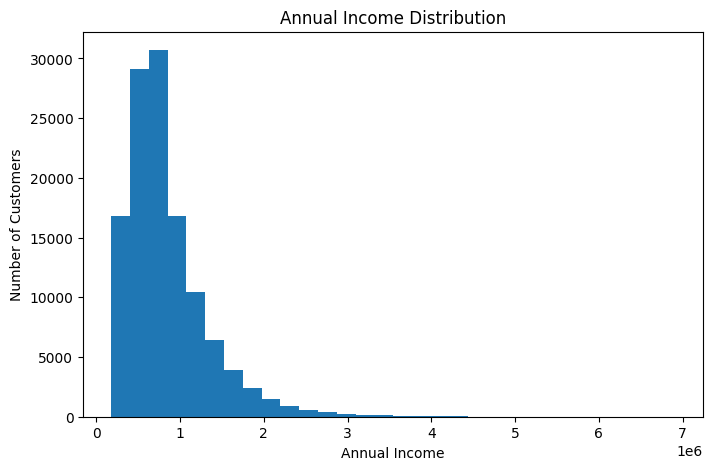

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df["annual_income"], bins=30)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

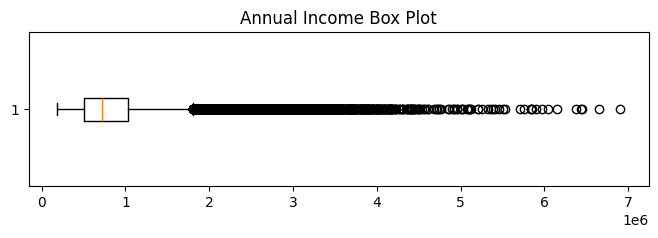

In [53]:
plt.figure(figsize=(8,2))
plt.boxplot(df["annual_income"], vert=False)

plt.title("Annual Income Box Plot")

plt.show()

In [54]:
# MONTHLY INCOME

In [55]:
df["monthly_income"].describe()

count    1.207200e+05
mean     7.505514e+04
std      1.327775e+05
min      1.500000e+04
25%      4.150000e+04
50%      6.030000e+04
75%      8.790000e+04
max      1.084120e+07
Name: monthly_income, dtype: float64

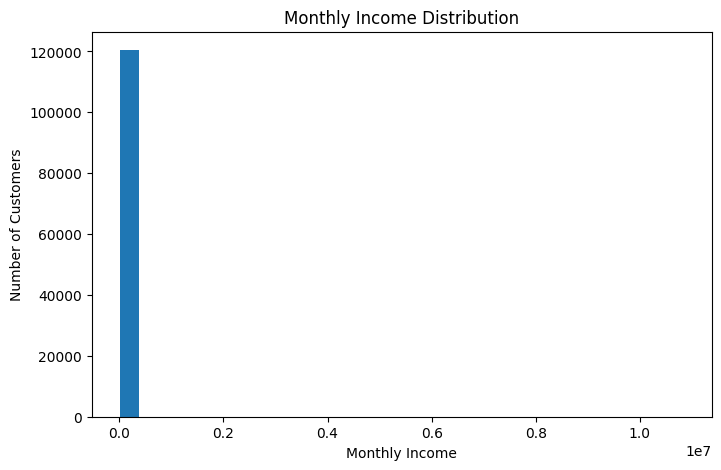

In [56]:
plt.figure(figsize=(8,5))
plt.hist(df["monthly_income"], bins=30)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")

plt.show()

In [57]:
df["monthly_income"].nlargest(10)

10284     1.084120e+07
93814     8.502901e+06
109689    8.269071e+06
72459     7.787240e+06
8417      6.968836e+06
16779     6.653520e+06
62945     6.313404e+06
3673      5.913059e+06
72765     5.813858e+06
98321     5.810316e+06
Name: monthly_income, dtype: float64

In [58]:
df["monthly_income"].quantile([0.90, 0.95, 0.99, 0.999])

0.900    1.239000e+05
0.950    1.525000e+05
0.990    2.297810e+05
0.999    2.012793e+06
Name: monthly_income, dtype: float64

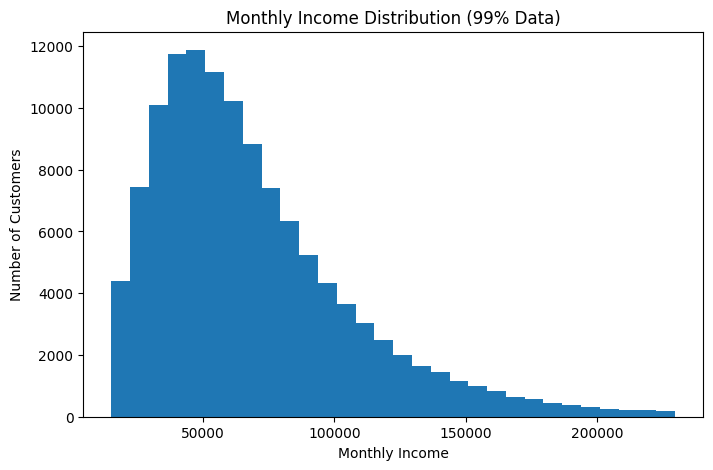

In [59]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["monthly_income"] <= df["monthly_income"].quantile(0.99)]["monthly_income"],
    bins=30
)

plt.title("Monthly Income Distribution (99% Data)")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")

plt.show()

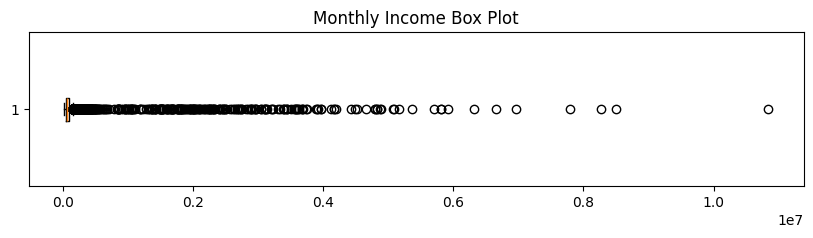

In [60]:
plt.figure(figsize=(10,2))

plt.boxplot(df["monthly_income"], vert=False)

plt.title("Monthly Income Box Plot")

plt.show()

In [61]:
#CRADIT SCORE ANALYSIS

In [62]:
df["credit_score"].describe()

count    120720.000000
mean        679.834220
std          87.307865
min         300.000000
25%         622.000000
50%         680.000000
75%         737.000000
max         900.000000
Name: credit_score, dtype: float64

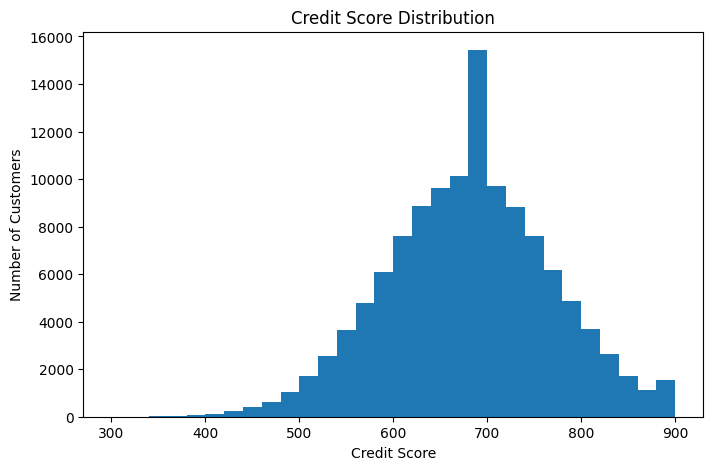

In [63]:
plt.figure(figsize=(8,5))

plt.hist(df["credit_score"], bins=30)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
#Debt-to-Income Ratio

In [65]:
df["debt_to_income_ratio"].describe()

count    120720.000000
mean          0.505958
std           0.308211
min           0.048000
25%           0.279000
50%           0.431000
75%           0.656000
max           1.400000
Name: debt_to_income_ratio, dtype: float64

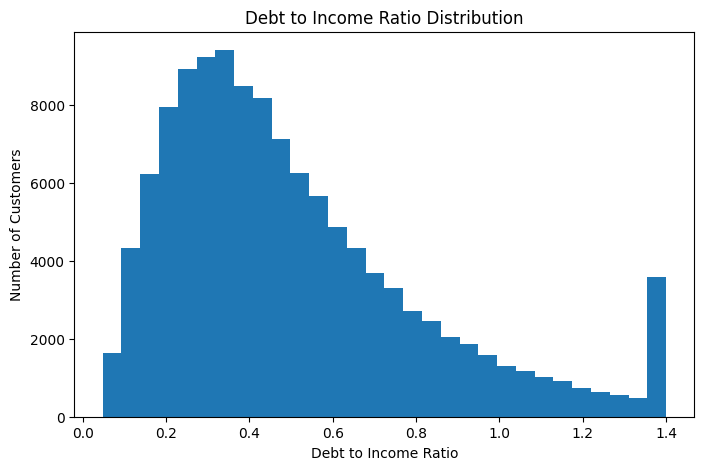

In [66]:
plt.figure(figsize=(8,5))
plt.hist(df["debt_to_income_ratio"], bins=30)

plt.title("Debt to Income Ratio Distribution")
plt.xlabel("Debt to Income Ratio")
plt.ylabel("Number of Customers")

plt.show()

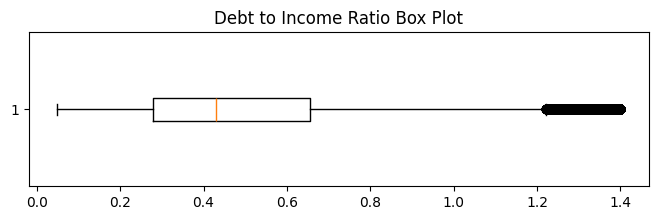

In [67]:
plt.figure(figsize=(8,2))
plt.boxplot(df["debt_to_income_ratio"], vert=False)

plt.title("Debt to Income Ratio Box Plot")

plt.show()

In [68]:
df.groupby("loan_status")["credit_score"].mean().round(2)

loan_status
Active         681.96
Closed         682.34
Default        640.01
Written-Off    643.11
Name: credit_score, dtype: float64

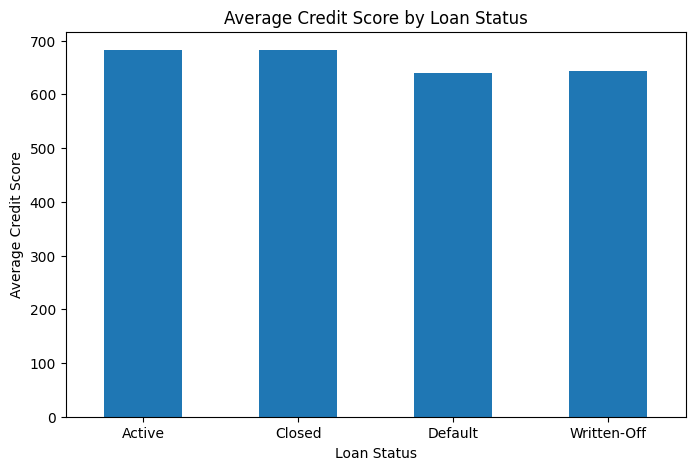

In [69]:
credit = df.groupby("loan_status")["credit_score"].mean()

plt.figure(figsize=(8,5))
credit.plot(kind="bar")

plt.title("Average Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Credit Score")

plt.xticks(rotation=0)

plt.show()

In [70]:
df.groupby("loan_status")["annual_income"].mean()

loan_status
Active         846570.578183
Closed         853586.029632
Default        686345.261740
Written-Off    682130.000000
Name: annual_income, dtype: float64

In [71]:
pd.crosstab(df["employment_type"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
employment_type,,,,
Business Owner,8367,3004,527,50
Salaried,46674,16622,2972,237
Self-Employed Business,16720,5935,1443,110
Self-Employed Professional,12503,4474,999,83


In [72]:
pd.crosstab(df["loan_product"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
loan_product,,,,
Auto Loan,24221,4748,1215,85
Business Loan,18364,4500,1150,92
Gold Loan,7655,9470,932,81
Personal Loan,34024,11317,2644,222


In [73]:
pd.crosstab(df["age_group"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
age_group,,,,
18-25,9598,3447,640,59
26-35,19170,6849,1360,101
36-45,19027,6759,1356,110
46-55,19072,6858,1355,109
56-64,17397,6122,1230,101


In [74]:
#goal


In [75]:
#AVERAGE CRADIT SCORE

In [79]:
df.groupby("loan_status")["annual_income"].mean().round(2)

loan_status
Active         846570.58
Closed         853586.03
Default        686345.26
Written-Off    682130.00
Name: annual_income, dtype: float64

In [80]:
pd.crosstab(df["employment_type"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
employment_type,,,,
Business Owner,8367,3004,527,50
Salaried,46674,16622,2972,237
Self-Employed Business,16720,5935,1443,110
Self-Employed Professional,12503,4474,999,83


In [81]:
pd.crosstab(df["risk_category"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
risk_category,,,,
High,201,104,219,16
Low,81170,27979,4524,354
Medium,2889,1951,1191,110
Very High,4,1,7,0


In [82]:
pd.crosstab(df["age_group"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
age_group,,,,
18-25,9598,3447,640,59
26-35,19170,6849,1360,101
36-45,19027,6759,1356,110
46-55,19072,6858,1355,109
56-64,17397,6122,1230,101


In [83]:
pd.crosstab(df["state"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
state,,,,
Andhra Pradesh,3390,1205,217,20
Bihar,3233,1103,450,35
Delhi,6731,2377,528,44
Gujarat,6862,2480,351,22
Haryana,3473,1175,197,19
Karnataka,6726,2452,432,29
Kerala,3451,1227,190,16
Madhya Pradesh,3421,1206,169,12
Maharashtra,6679,2332,432,35


In [84]:
df.groupby("loan_status")["annual_income"].mean().round(2)

loan_status
Active         846570.58
Closed         853586.03
Default        686345.26
Written-Off    682130.00
Name: annual_income, dtype: float64

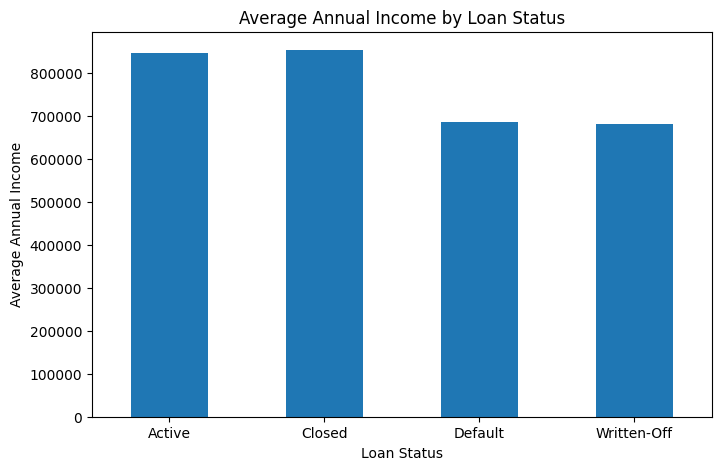

In [85]:
income = df.groupby("loan_status")["annual_income"].mean()

plt.figure(figsize=(8,5))
income.plot(kind="bar")

plt.title("Average Annual Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Annual Income")

plt.xticks(rotation=0)
plt.show()

In [86]:
pd.crosstab(df["employment_type"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
employment_type,,,,
Business Owner,8367,3004,527,50
Salaried,46674,16622,2972,237
Self-Employed Business,16720,5935,1443,110
Self-Employed Professional,12503,4474,999,83


In [87]:
pd.crosstab(
    df["employment_type"],
    df["loan_status"],
    normalize="index"
).round(2) * 100

loan_status,Active,Closed,Default,Written-Off
employment_type,,,,
Business Owner,70.0,25.0,4.0,0.0
Salaried,70.0,25.0,4.0,0.0
Self-Employed Business,69.0,25.0,6.0,0.0
Self-Employed Professional,69.0,25.0,6.0,0.0


In [88]:
# Total Loans
df.shape[0]

# Total Loan Amount
df["loan_amount"].sum()

# Average Loan Amount
df["loan_amount"].mean()

# Average Credit Score
df["credit_score"].mean()

# Default Rate
(df["loan_status"] == "Default").mean() * 100

# NPA Rate
(df["npa_flag"] == "Yes").mean() * 100

np.float64(4.358846918489066)

In [89]:
df.groupby("loan_status")["credit_score"].mean().round(2)

loan_status
Active         681.96
Closed         682.34
Default        640.01
Written-Off    643.11
Name: credit_score, dtype: float64

In [90]:
df.groupby("loan_status")["annual_income"].mean().round(2)

loan_status
Active         846570.58
Closed         853586.03
Default        686345.26
Written-Off    682130.00
Name: annual_income, dtype: float64

In [91]:
pd.crosstab(
    df["employment_type"],
    df["loan_status"],
    normalize="index"
).round(2) * 100

loan_status,Active,Closed,Default,Written-Off
employment_type,,,,
Business Owner,70.0,25.0,4.0,0.0
Salaried,70.0,25.0,4.0,0.0
Self-Employed Business,69.0,25.0,6.0,0.0
Self-Employed Professional,69.0,25.0,6.0,0.0


In [92]:
pd.crosstab(df["loan_product"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
loan_product,,,,
Auto Loan,24221,4748,1215,85
Business Loan,18364,4500,1150,92
Gold Loan,7655,9470,932,81
Personal Loan,34024,11317,2644,222


In [93]:
pd.crosstab(df["risk_category"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
risk_category,,,,
High,201,104,219,16
Low,81170,27979,4524,354
Medium,2889,1951,1191,110
Very High,4,1,7,0


In [94]:
pd.crosstab(df["state"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
state,,,,
Andhra Pradesh,3390,1205,217,20
Bihar,3233,1103,450,35
Delhi,6731,2377,528,44
Gujarat,6862,2480,351,22
Haryana,3473,1175,197,19
Karnataka,6726,2452,432,29
Kerala,3451,1227,190,16
Madhya Pradesh,3421,1206,169,12
Maharashtra,6679,2332,432,35


In [95]:
pd.crosstab(df["customer_segment"], df["loan_status"])

loan_status,Active,Closed,Default,Written-Off
customer_segment,,,,
Mass Affluent,38568,13846,1913,159
Mass Market,41299,14557,3874,313
Premium,4397,1632,154,8


In [96]:
df.groupby("loan_status")["debt_to_income_ratio"].mean().round(2)

loan_status
Active         0.43
Closed         0.66
Default        0.71
Written-Off    0.73
Name: debt_to_income_ratio, dtype: float64

In [97]:
corr = df[
    [
        "annual_income",
        "loan_amount",
        "credit_score",
        "emi_amount",
        "debt_to_income_ratio"
    ]
].corr()

corr

,annual_income,loan_amount,credit_score,emi_amount,debt_to_income_ratio
annual_income,1.000000,0.634230,0.003519,0.579308,-0.223793
loan_amount,0.634230,1.000000,0.005854,0.595347,0.010708
credit_score,0.003519,0.005854,1.000000,0.000634,-0.005115
emi_amount,0.579308,0.595347,0.000634,1.000000,0.343326
debt_to_income_ratio,-0.223793,0.010708,-0.005115,0.343326,1.000000


In [98]:
num_cols = [
    "annual_income",
    "monthly_income",
    "loan_amount",
    "sanctioned_amount",
    "disbursed_amount",
    "interest_rate",
    "emi_amount",
    "credit_score",
    "debt_to_income_ratio",
    "existing_emi_obligations",
    "payment_history_score"
]

In [99]:
corr = df[num_cols].corr()

corr

,annual_income,monthly_income,loan_amount,sanctioned_amount,disbursed_amount,interest_rate,emi_amount,credit_score,debt_to_income_ratio,existing_emi_obligations,payment_history_score
annual_income,1.000000,0.332604,0.634230,0.785801,0.785730,-0.000188,0.579308,0.003519,-0.223793,0.004634,0.128335
monthly_income,0.332604,1.000000,0.224061,0.278742,0.278746,0.003174,0.203442,-0.003028,-0.077968,0.000492,0.043210
loan_amount,0.634230,0.224061,1.000000,0.804555,0.804518,-0.000783,0.595347,0.005854,0.010708,0.005726,0.033027
sanctioned_amount,0.785801,0.278742,0.804555,1.000000,0.999891,0.000419,0.737061,0.003214,0.013788,0.004130,0.038536
disbursed_amount,0.785730,0.278746,0.804518,0.999891,1.000000,0.000565,0.737084,0.003247,0.013859,0.004123,0.038556
interest_rate,-0.000188,0.003174,-0.000783,0.000419,0.000565,1.000000,-0.054612,0.002447,-0.045785,-0.000043,0.004874
emi_amount,0.579308,0.203442,0.595347,0.737061,0.737084,-0.054612,1.000000,0.000634,0.343326,0.001516,-0.100818
credit_score,0.003519,-0.003028,0.005854,0.003214,0.003247,0.002447,0.000634,1.000000,-0.005115,-0.006074,0.082979
debt_to_income_ratio,-0.223793,-0.077968,0.010708,0.013788,0.013859,-0.045785,0.343326,-0.005115,1.000000,0.587793,-0.433295
existing_emi_obligations,0.004634,0.000492,0.005726,0.004130,0.004123,-0.000043,0.001516,-0.006074,0.587793,1.000000,-0.252647


In [100]:
import seaborn as sns

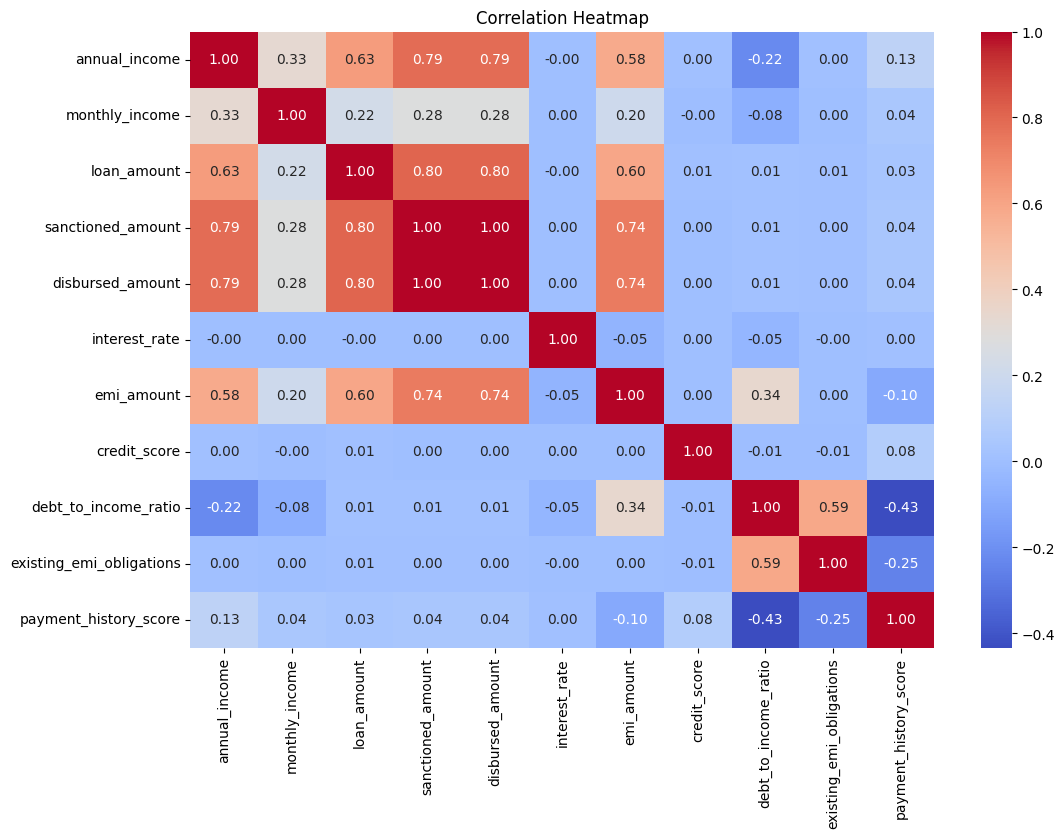

In [101]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [103]:
#Customers with lower credit scores show a higher likelihood of default, indicating that credit score is a strong indicator of repayment risk.

In [104]:
df.to_csv("../DATA/eda_loan_data.csv", index=False)
print("✅ EDA dataset saved successfully!")

✅ EDA dataset saved successfully!
